<a id="02"></a>

## 02 — Time Domain Analysis
### Phần đầu của mục 0.2 — So sánh dạng sóng miền thời gian

**Mục đích**: so sánh trực quan dạng sóng của 4 nhãn (Normal, Inner Race,
Outer Race, Ball) tại **cùng một mức tải**, quan sát sự khác biệt về biên
độ và tính xung (impulsiveness) — lỗi cơ khí thường biểu hiện dưới dạng
các xung lặp lại theo chu kỳ, trong khi Normal thì không.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from typing import Any
from matplotlib.patches import Rectangle

from common import io_utils, pipeline, synthetic, dsp, features, splitting, config as cfg

pd.set_option("display.max_colwidth", 120)

In [3]:
USE_SYNTHETIC_DATA = False
REAL_DATA_ROOT = Path("../../data/raw")            # <-- data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = True

FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=FORCE_REBUILD_MANIFEST,
)
print(f"Tổng số file trong manifest: {len(manifest)}")
manifest.head()

Tổng số file trong manifest: 161


,file_path,load_hp,label,fault_diameter_mils,or_position,source_category,sensor_location,declared_sample_rate_khz,n_samples_DE,n_samples_FE,n_samples_BA,rpm_from_file,read_error,warnings,has_warning
0,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat,0,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,122571,122571.0,122571.0,1796.0,None,,False
1,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\119_1.mat,1,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121410,121410.0,121410.0,1772.0,None,,False
2,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\120_2.mat,2,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1748.0,None,,False
3,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\121_3.mat,3,B,7.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121556,121556.0,121556.0,1722.0,None,,False
4,..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\014\185_0.mat,0,B,14.0,NaN,12k_Drive_End_Bearing_Fault_Data,DE,12.0,121846,121846.0,121846.0,1796.0,None,,False


## Lọc phạm vi dữ liệu (mục 0.1/0.4) — TRƯỚC khi phân tích

`manifest` gốc còn chứa cả file NGOÀI phạm vi đã chốt (vòng bi NTN đường
kính 28/40 mils, vị trí Outer Race Orthogonal/Opposite). Nếu không lọc ở
đây, các bước chọn "file đại diện" bên dưới có thể vô tình chọn nhầm — vd
chọn file OR vị trí Orthogonal/Opposite trong khi đề tài chỉ dùng Centered.

In [5]:
manifest = io_utils.apply_scope_filter(manifest)

Áp dụng bộ lọc phạm vi (mục 0.1/0.4):
  - Loại 8 file có cảnh báo 'VONG_BI_NTN'
  - Loại 47 file có cảnh báo 'OR_NGOAI_PHAM_VI'
  - Loại 0 file có cảnh báo 'OR_THIEU_VI_TRI'
  - Loại 0 file có cảnh báo 'THIEU_NHAN'
  - Loại 0 file có cảnh báo 'THIEU_TAI'
  - Loại 0 file có cảnh báo 'DUONG_KINH_LA'
  - Loại 45 file có cảnh báo 'NGOAI_PHAM_VI_CAM_BIEN'
  - Loại 52 file có cảnh báo 'NGOAI_PHAM_VI_TAN_SO_KHAI_BAO'
  - Loại 0 file có cảnh báo 'THIEU_TIN_HIEU_DE'
  - Loại 0 file có cảnh báo 'LOI_DOC_FILE'
Tổng: loại 121/161 file — còn lại 40 file.


## Chọn 1 file đại diện mỗi nhãn, cùng mức tải

In [11]:
LOAD_HP = 0  # đổi mức tải muốn xem tại đây

labels_to_plot = ["Normal", "IR", "OR", "B"]
signals = {}
for label in labels_to_plot:
    fp = pipeline.pick_file(manifest, label=label, load_hp=LOAD_HP)
    signals[label] = io_utils.load_de_signal(Path(fp))
    print(f"{label:8s}: {fp}  ({len(signals[label])} mẫu)")

Normal  : ..\..\data\raw\Normal\97_Normal_0.mat  (243938 mẫu)
IR      : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\IR\007\105_0.mat  (121265 mẫu)
OR      : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\OR\007\@6\130@6_0.mat  (121991 mẫu)
B       : ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\B\007\118_0.mat  (122571 mẫu)


## Vẽ chồng dạng sóng ở miền thời gian

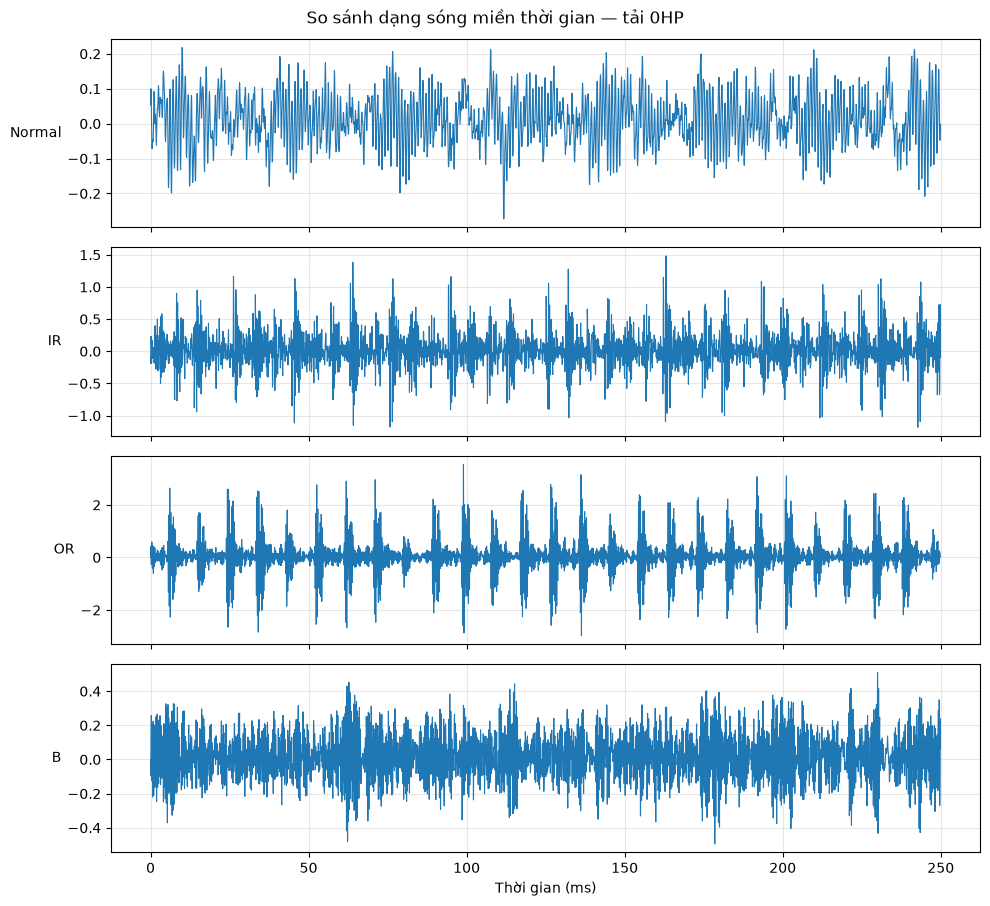

In [7]:
FS = 12000  # sampling rate của dữ liệu đang phân tích (đổi nếu khác)
N_SECONDS = 0.25  # chỉ xem 250ms đầu cho dễ quan sát tính xung

fig, axes = plt.subplots(len(signals), 1, figsize=(10, 2.3 * len(signals)), sharex=True)
n_samples_plot = int(N_SECONDS * FS)
t_ms = np.arange(n_samples_plot) / FS * 1000

for ax, (label, x) in zip(axes, signals.items()):
    ax.plot(t_ms, x[:n_samples_plot], linewidth=0.8)
    ax.set_ylabel(label, rotation=0, ha="right", va="center")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Thời gian (ms)")
fig.suptitle(f"So sánh dạng sóng miền thời gian — tải {LOAD_HP}HP")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_time_domain_comparison.png", dpi=150)
plt.show()

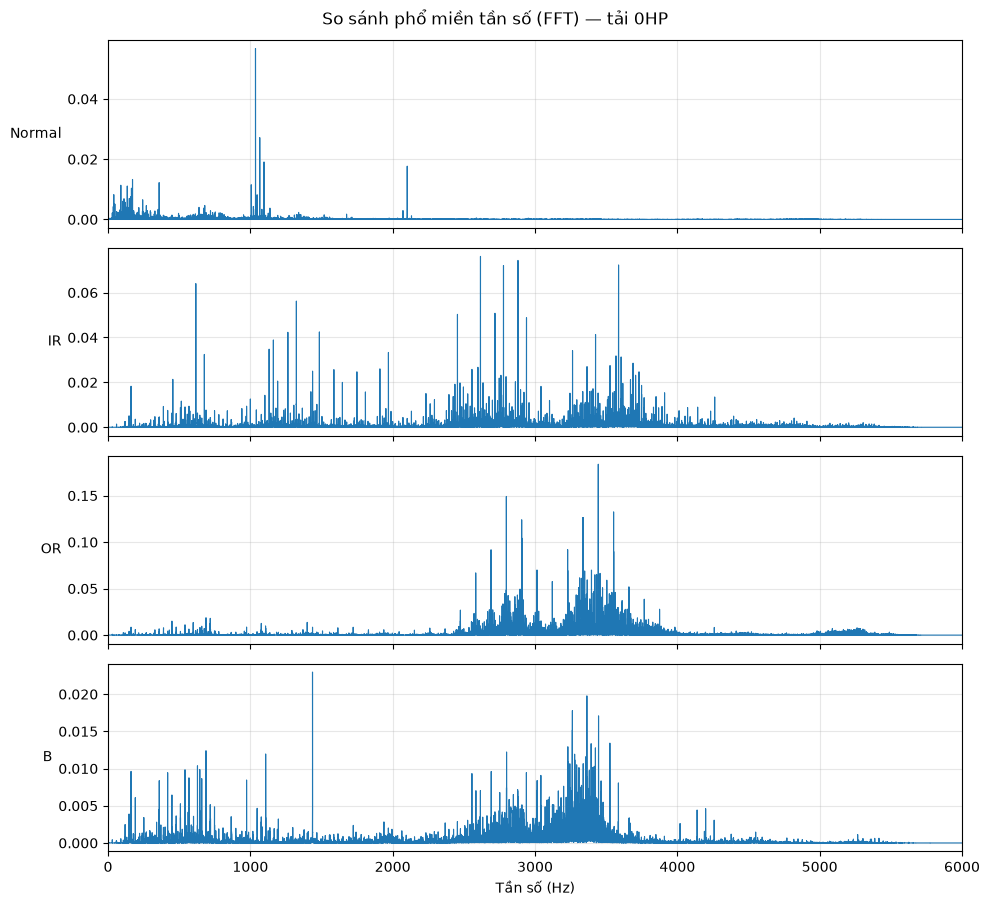

In [8]:
import numpy as np
import matplotlib.pyplot as plt

FS = 12000  # sampling rate của dữ liệu đang phân tích

fig, axes = plt.subplots(len(signals), 1, figsize=(10, 2.3 * len(signals)), sharex=True)

for ax, (label, x) in zip(axes, signals.items()):
    N = len(x)
    
    # 1. Tính toán biến đổi Fourier (nửa phổ dương cho tín hiệu thực)
    yf = np.fft.rfft(x)
    xf = np.fft.rfftfreq(N, 1 / FS)
    
    # 2. Chuẩn hóa biên độ (Amplitude)
    # Chia cho N và nhân 2 (ngoại trừ thành phần DC) để phản ánh đúng biên độ vật lý
    amplitude = np.abs(yf) / N
    amplitude[1:] = 2 * amplitude[1:]
    
    # 3. Vẽ đồ thị
    ax.plot(xf, amplitude, linewidth=0.8, color='#1f77b4')
    ax.set_ylabel(label, rotation=0, ha="right", va="center")
    ax.grid(alpha=0.3)
    
    # Giới hạn trục x từ 0 đến tần số Nyquist (6000 Hz)
    ax.set_xlim(0, FS / 2)

axes[-1].set_xlabel("Tần số (Hz)")
fig.suptitle(f"So sánh phổ miền tần số (FFT) — tải {LOAD_HP}HP")
fig.tight_layout()

# Nhớ thay đổi tên file lưu trữ để không đè lên hình miền thời gian
# fig.savefig(FIGURES_DIR / "03_frequency_domain_comparison.png", dpi=150)
plt.show()

## Quan sát

Điền nhận xét thực tế sau khi chạy với dữ liệu CWRU thật:
- Nhãn nào có biên độ đỉnh (peak) lớn nhất?
- Nhãn nào thể hiện rõ tính xung (các đỉnh nhọn lặp lại theo chu kỳ) nhất?
- Normal có đặc điểm gì khác biệt rõ rệt so với 3 nhãn lỗi?

Hình đã lưu tại `outputs/figures/02_time_domain_comparison.png` — dùng
trực tiếp cho phần Cơ sở lý thuyết của báo cáo.